# Preprocessing — NSL-KDD Dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

PROCESSED = os.path.join(os.path.dirname(os.getcwd()), 'data', 'processed')
os.makedirs(PROCESSED, exist_ok=True)

## 1. Load & Label

In [2]:
cols = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

label_map = {
    'normal':'Normal',
    'neptune':'DoS','back':'DoS','land':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe','mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L','phf':'R2L','spy':'R2L',
    'warezclient':'R2L','warezmaster':'R2L','sendmail':'R2L','named':'R2L','snmpgetattack':'R2L',
    'snmpguess':'R2L','xlock':'R2L','xsnoop':'R2L','worm':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R',
    'httptunnel':'U2R','ps':'U2R','sqlattack':'U2R','xterm':'U2R'
}

def load(path):
    df = pd.read_csv(path, names=cols)
    df.drop('difficulty', axis=1, inplace=True)
    df['label'] = df['label'].map(label_map)
    df.dropna(subset=['label'], inplace=True)
    return df

train = load(os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'KDDTrain+.txt'))
test  = load(os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'KDDTest+.txt'))

print('Train:', train.shape, '  Test:', test.shape)
print(train['label'].value_counts())

Train: (125973, 42)   Test: (22544, 42)
label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


## 2. Encode Categorical Features

In [3]:
cat_cols = ['protocol_type', 'service', 'flag']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col]  = test[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    encoders[col] = le

joblib.dump(encoders, os.path.join(PROCESSED, 'label_encoders.pkl'))
print('Categorical features encoded and saved.')

Categorical features encoded and saved.


## 3. Encode Target Label

In [4]:
target_enc = LabelEncoder()
train['label_enc'] = target_enc.fit_transform(train['label'])
test['label_enc']  = test['label'].apply(lambda x: target_enc.transform([x])[0] if x in target_enc.classes_ else -1)

joblib.dump(target_enc, os.path.join(PROCESSED, 'target_encoder.pkl'))
print('Classes:', list(target_enc.classes_))

Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']


## 4. Drop Zero-Variance Features

In [5]:
feature_cols = [c for c in train.columns if c not in ['label', 'label_enc']]
zero_var = [c for c in feature_cols if train[c].nunique() == 1]

train.drop(columns=zero_var, inplace=True)
test.drop(columns=zero_var, inplace=True)
feature_cols = [c for c in train.columns if c not in ['label', 'label_enc']]

print('Dropped:', zero_var)
print('Features remaining:', len(feature_cols))

Dropped: ['num_outbound_cmds']
Features remaining: 40


## 5. Train / Validation Split

In [6]:
X       = train[feature_cols].values
y       = train['label_enc'].values
X_test  = test[feature_cols].values
y_test  = test['label_enc'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)

Train: (100778, 40)  Val: (25195, 40)  Test: (22544, 40)


## 6. SMOTE — Fix Class Imbalance

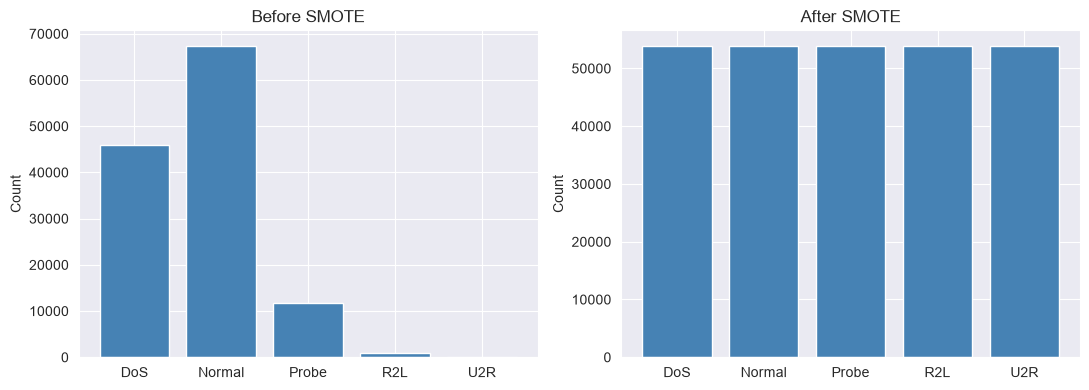

In [7]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Before vs After chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_data, title in zip(axes, [y, y_train], ['Before SMOTE', 'After SMOTE']):
    vals, cnts = np.unique(y_data, return_counts=True)
    ax.bar(target_enc.classes_, cnts, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 7. Scale Features

In [8]:
scaler     = StandardScaler()
X_train    = scaler.fit_transform(X_train)
X_val      = scaler.transform(X_val)
X_test     = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(PROCESSED, 'scaler.pkl'))
print(f'Scaled. Mean: {X_train.mean():.4f}  Std: {X_train.std():.4f}')

Scaled. Mean: -0.0000  Std: 1.0000


## 8. Save Processed Data

In [9]:
np.save(os.path.join(PROCESSED, 'X_train.npy'), X_train)
np.save(os.path.join(PROCESSED, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED, 'X_val.npy'),   X_val)
np.save(os.path.join(PROCESSED, 'y_val.npy'),   y_val)
np.save(os.path.join(PROCESSED, 'X_test.npy'),  X_test)
np.save(os.path.join(PROCESSED, 'y_test.npy'),  y_test)
joblib.dump(feature_cols, os.path.join(PROCESSED, 'feature_names.pkl'))

print('Saved to data/processed/:')
for f in sorted(os.listdir(PROCESSED)):
    print(f'  {f}')

Saved to data/processed/:
  X_test.npy
  X_train.npy
  X_val.npy
  feature_names.pkl
  label_encoders.pkl
  scaler.pkl
  target_encoder.pkl
  y_test.npy
  y_train.npy
  y_val.npy


## 9. Sanity Check

In [10]:
X_tr = np.load(os.path.join(PROCESSED, 'X_train.npy'))
y_tr = np.load(os.path.join(PROCESSED, 'y_train.npy'))

print('X_train shape:', X_tr.shape)
print('Any NaN:', np.isnan(X_tr).any())
print('\nFinal class distribution:')
vals, cnts = np.unique(y_tr, return_counts=True)
for cls, cnt in zip(target_enc.classes_, cnts):
    print(f'  {cls}: {cnt}')

X_train shape: (269370, 40)
Any NaN: False

Final class distribution:
  DoS: 53874
  Normal: 53874
  Probe: 53874
  R2L: 53874
  U2R: 53874
